# Stage 12 — Build Deliverable Figures (ASML)
Exports polished charts to `project/deliverables/images/` for the stakeholder report.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from dotenv import load_dotenv

# Resolve project root if running from project/notebooks
project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(project_root / "src"))

load_dotenv(project_root / ".env")
from storage import env_paths, read_df, write_df
from evaluation import rmse, bootstrap_ci

RAW_DIR, PROC_DIR = env_paths(project_root)
IMG_DIR = project_root / "deliverables" / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def stamp(): return datetime.now().strftime("%Y%m%d-%H%M")
plt.rcParams["figure.figsize"] = (10, 5)  # consistent sizing


In [2]:
feat_candidates  = sorted(PROC_DIR.glob("asml_features_*.parquet")) + sorted(PROC_DIR.glob("asml_features_*.csv"))
clean_candidates = sorted(PROC_DIR.glob("asml_cleaned_*.parquet")) + sorted(PROC_DIR.glob("asml_cleaned_*.csv"))
raw_candidates   = sorted(RAW_DIR.glob("api_*ASML_*.csv"))

if feat_candidates:
    path = feat_candidates[-1]
    print("Using FEATURES:", path.name)
    df = read_df(path, parse_dates=["date"])
elif clean_candidates:
    path = clean_candidates[-1]
    print("Using CLEANED:", path.name)
    df = read_df(path, parse_dates=["date"])
else:
    path = raw_candidates[-1]
    print("Using RAW:", path.name)
    df = read_df(path, parse_dates=["date"])

df = df.sort_values("date").reset_index(drop=True)
price_col = "adjusted_close" if "adjusted_close" in df.columns else "close"

# Ensure target exists
if "y_next_ret" not in df.columns:
    df["y_next_ret"] = df[price_col].pct_change().shift(-1)

# Feature set (use what exists)
cand = ["mom_5","mom_21","rsi_14","ret","ret_lag1","ret_mean_5","ret_std_21","ret_z_21","vol_21","range_21",
        "is_month_end","is_quarter_end"] + [c for c in df.columns if c.startswith("dow_")]
X_cols = [c for c in cand if c in df.columns]
X = df[X_cols].copy()
y = df["y_next_ret"].copy()
dates = df["date"].copy()

mask = X.notna().all(axis=1) & y.notna()
X, y, dates = X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True), dates.loc[mask].reset_index(drop=True)

# Time-aware split
split = int(len(X) * 0.80)
X_tr, X_te = X.iloc[:split, :], X.iloc[split:, :]
y_tr, y_te = y.iloc[:split], y.iloc[split:]
d_tr, d_te = dates.iloc[:split], dates.iloc[split:]
len(X_tr), len(X_te)


Using FEATURES: asml_features_20250821-1006.csv


(987, 247)

Baseline fit and metrics

In [3]:
pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe.fit(X_tr, y_tr)
yhat_tr = pipe.predict(X_tr)
yhat_te = pipe.predict(X_te)

metrics = {
    "r2_train": r2_score(y_tr, yhat_tr),
    "r2_test":  r2_score(y_te, yhat_te),
    "mae_train": mean_absolute_error(y_tr, yhat_tr),
    "mae_test":  mean_absolute_error(y_te, yhat_te),
    "rmse_train": float(np.sqrt(mean_squared_error(y_tr, yhat_tr))),
    "rmse_test":  float(np.sqrt(mean_squared_error(y_te, yhat_te))),
}
pd.DataFrame(metrics, index=["baseline"]).T


,baseline
r2_train,0.009437
r2_test,-0.001190
mae_train,0.019331
mae_test,0.018186
rmse_train,0.025653
rmse_test,0.027311


Figure 1: True vs Pred (test) with Gaussian band (export)

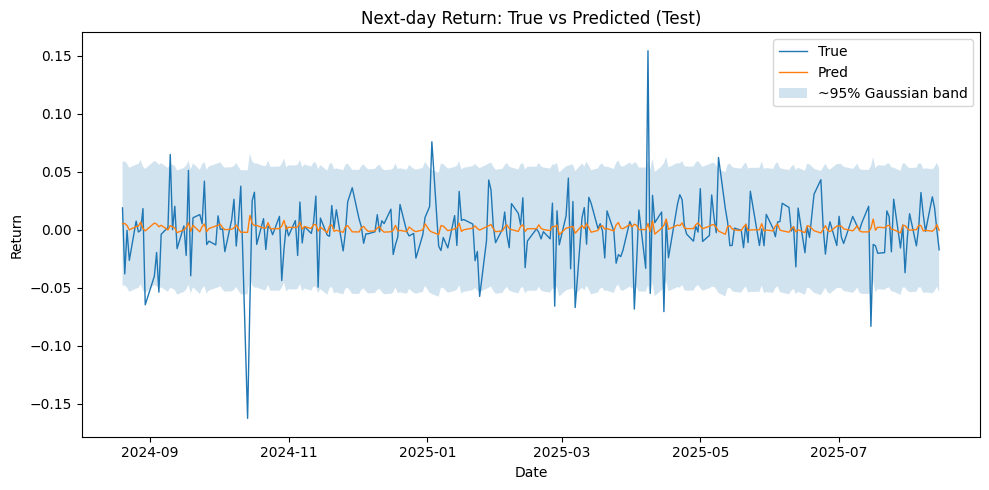

WindowsPath('C:/Users/melin/OneDrive/Desktop/nyu/python/bootcamp_panagiotis_housos/project/deliverables/images/fig1_pred_vs_true_with_gaussian_band.png')

In [4]:
sigma = float(np.std(y_te.to_numpy() - yhat_te, ddof=1))
upper = yhat_te + 1.96 * sigma
lower = yhat_te - 1.96 * sigma

plt.figure()
plt.plot(d_te, y_te.to_numpy(), label="True", linewidth=1)
plt.plot(d_te, yhat_te, label="Pred", linewidth=1)
plt.fill_between(d_te, lower, upper, alpha=0.20, label="~95% Gaussian band")
plt.title("Next-day Return: True vs Predicted (Test)"); plt.xlabel("Date"); plt.ylabel("Return")
plt.legend(); plt.tight_layout()
out1 = IMG_DIR / "fig1_pred_vs_true_with_gaussian_band.png"
plt.savefig(out1, dpi=300)
plt.show()
out1


Figure 2: Scenario RMSE with bootstrap CIs (baseline vs polynomial) (export)

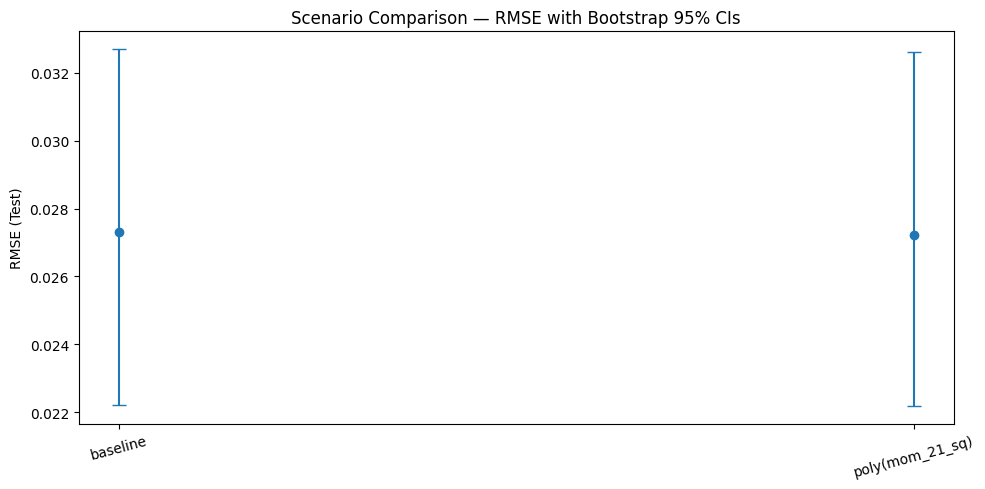

In [5]:
# Build scenario with a squared term if available
X_poly = X.copy()
added_term = None
if "mom_21" in X_poly.columns:
    X_poly["mom_21_sq"] = X_poly["mom_21"]**2
    added_term = "mom_21_sq"
elif "rsi_14" in X_poly.columns:
    X_poly["rsi_14_sq"] = X_poly["rsi_14"]**2
    added_term = "rsi_14_sq"

if added_term:
    Xp_tr, Xp_te = X_poly.iloc[:split, :], X_poly.iloc[split:, :]
    pipe2 = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    pipe2.fit(Xp_tr, y_tr)
    yhat_te_poly = pipe2.predict(Xp_te)

    # Bootstrap 95% CI for RMSE in each scenario
    lo_b0, hi_b0, _ = bootstrap_ci(y_te.to_numpy(), yhat_te, metric=rmse, n_boot=1000, seed=7)
    lo_b1, hi_b1, _ = bootstrap_ci(y_te.to_numpy(), yhat_te_poly, metric=rmse, n_boot=1000, seed=7)

    scen = pd.DataFrame({
        "scenario": ["baseline", f"poly({added_term})"],
        "rmse": [rmse(y_te.to_numpy(), yhat_te), rmse(y_te.to_numpy(), yhat_te_poly)],
        "lo":   [lo_b0, lo_b1],
        "hi":   [hi_b0, hi_b1],
    })

    # Plot with error bars
    plt.figure()
    x = np.arange(len(scen))
    point = scen["rmse"].to_numpy()
    low   = point - scen["lo"].to_numpy()
    high  = scen["hi"].to_numpy() - point
    plt.errorbar(x, point, yerr=[low, high], fmt='o', capsize=5)
    plt.xticks(x, scen["scenario"].tolist(), rotation=15)
    plt.ylabel("RMSE (Test)")
    plt.title("Scenario Comparison — RMSE with Bootstrap 95% CIs")
    plt.tight_layout()
    out2 = IMG_DIR / "fig2_scenario_rmse_bootstrap.png"
    plt.savefig(out2, dpi=300)
    plt.show()

    scen_out = IMG_DIR / "table_scenario_rmse.csv"
    scen.to_csv(scen_out, index=False)
    out2, scen_out
else:
    print("No candidate column for polynomial term; skip Figure 2.")


Figure 3: Subgroup performance by volatility regime

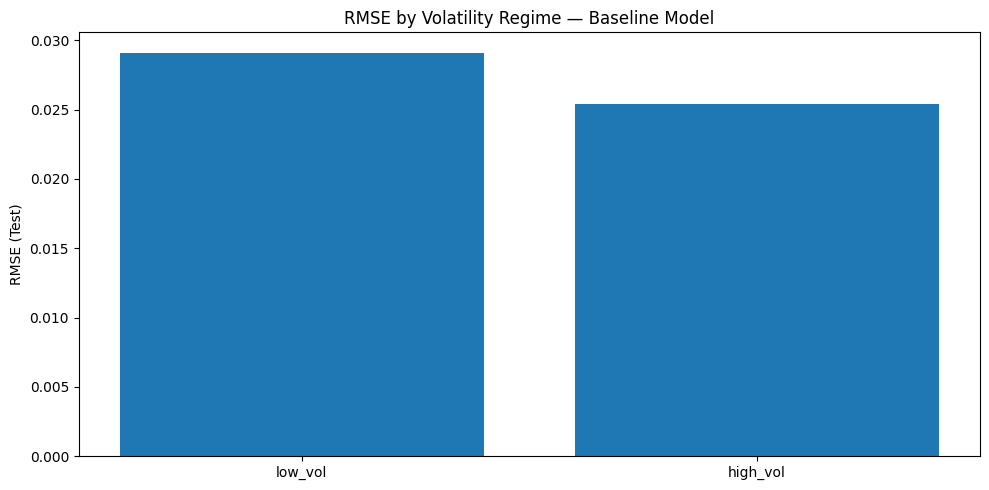

(WindowsPath('C:/Users/melin/OneDrive/Desktop/nyu/python/bootcamp_panagiotis_housos/project/deliverables/images/fig3_rmse_by_vol_regime.png'),
 WindowsPath('C:/Users/melin/OneDrive/Desktop/nyu/python/bootcamp_panagiotis_housos/project/deliverables/images/table_regime_rmse.csv'))

In [6]:
# Define high/low volatility on TEST set
if "vol_21" in X.columns:
    vol = X.loc[X_te.index, "vol_21"]
else:
    vol = X.loc[X_te.index, "ret_std_21"] if "ret_std_21" in X.columns else X.loc[X_te.index, "ret_mean_5"].abs()

threshold = vol.median()
regime = np.where(vol > threshold, "high_vol", "low_vol")

df_te = pd.DataFrame({"y": y_te.to_numpy(), "yhat": yhat_te, "regime": regime})
rmse_low  = rmse(df_te.loc[df_te["regime"]=="low_vol",  "y"].to_numpy(),
                 df_te.loc[df_te["regime"]=="low_vol",  "yhat"].to_numpy())
rmse_high = rmse(df_te.loc[df_te["regime"]=="high_vol", "y"].to_numpy(),
                 df_te.loc[df_te["regime"]=="high_vol", "yhat"].to_numpy())

plt.figure()
plt.bar(["low_vol","high_vol"], [rmse_low, rmse_high])
plt.ylabel("RMSE (Test)"); plt.title("RMSE by Volatility Regime — Baseline Model")
plt.tight_layout()
out3 = IMG_DIR / "fig3_rmse_by_vol_regime.png"
plt.savefig(out3, dpi=300)
plt.show()

# Save a small sensitivity table for the report
sens_tbl = pd.DataFrame({
    "Assumption/Segment": ["Volatility Regime: low_vol", "Volatility Regime: high_vol"],
    "RMSE": [rmse_low, rmse_high]
})
sens_out = IMG_DIR / "table_regime_rmse.csv"
sens_tbl.to_csv(sens_out, index=False)
out3, sens_out
